In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_data/egx100.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

In [3]:
df.shape

(1306, 6)

In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1306 entries, 2015-01-04 to 2020-05-07
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       1306 non-null   float64
 1   open        1306 non-null   float64
 2   high        1306 non-null   float64
 3   low         1306 non-null   float64
 4   vol         1294 non-null   float64
 5   change_pct  1306 non-null   float64
dtypes: float64(6)
memory usage: 71.4 KB


In [5]:
df.head()

,price,open,high,low,vol,change_pct
date,,,,,,
2015-01-04,1095.25,1090.70,1095.67,1088.04,69.38,0.44
2015-01-05,1108.45,1095.72,1110.11,1095.64,99.04,1.21
2015-01-06,1095.09,1106.46,1106.46,1092.67,115.59,-1.21
2015-01-08,1111.65,1096.89,1111.67,1096.89,90.19,1.51
2015-01-11,1110.74,1111.71,1113.37,1110.37,53.21,-0.08


In [6]:
df.tail()

,price,open,high,low,vol,change_pct
date,,,,,,
2020-05-03,1101.29,1134.08,1134.08,1101.29,374.90,-2.89
2020-05-04,1088.93,1101.29,1101.29,1086.47,305.05,-1.12
2020-05-05,1107.07,1088.93,1107.18,1088.93,234.02,1.67
2020-05-06,1118.31,1107.07,1119.80,1107.07,225.18,1.02
2020-05-07,1084.95,1118.31,1119.61,1084.95,320.26,-2.98


In [7]:
#print null count
print(df.isnull().sum())

price          0
open           0
high           0
low            0
vol           12
change_pct     0
dtype: int64


In [8]:
#fill missing values in volume colummn with mean
df['vol'] = df['vol'].fillna(df['vol'].mean())

In [9]:
#Computing daily % return 
df['return'] = df['price'].pct_change()

In [10]:
#Adding lag features
df['return_lag1'] = df['return'].shift(1)
df['return_lag2'] = df['return'].shift(2)

In [11]:
#Adding rolling features
df['ma_20']         = df['price'].rolling(20).mean()
df['volatility_20'] = df['return'].rolling(20).std()
df['ma_5']          = df['price'].rolling(5).mean()

In [12]:
df['dist_to_ma5'] = (df['price'] / df['ma_5']) - 1
df['dist_to_ma20'] = (df['price'] / df['ma_20']) - 1

In [13]:
# 1. Calculate the Fast (12-day) and Slow (26-day) Exponential Moving Averages (EMA)
ema_12 = df['price'].ewm(span=12, adjust=False).mean()
ema_26 = df['price'].ewm(span=26, adjust=False).mean()

# 2. Calculate the raw MACD line
df['macd'] = ema_12 - ema_26

# 3. Calculate the Signal Line (9-day EMA of the MACD)
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()

# 4. Calculate the MACD Histogram (The most useful feature for ML)
# This represents the distance between the MACD and its signal line
df['macd_hist'] = df['macd'] - df['macd_signal']

# What this does: A rising macd_hist means short-term momentum is accelerating upward.

In [14]:
# 1. Calculate the 20-day SMA (Middle Band) and 20-day Standard Deviation
window = 20
sma_20 = df['price'].rolling(window=window).mean()
std_20 = df['price'].rolling(window=window).std()

# 2. Calculate Upper and Lower Bands
upper_band = sma_20 + (std_20 * 2)
lower_band = sma_20 - (std_20 * 2)

# 3. Feature A: Bollinger %B (Where is price relative to the bands?)
# Value of 1.0 = price is touching upper band. Value of 0.0 = touching lower band.
df['bb_pb'] = (df['price'] - lower_band) / (upper_band - lower_band)

# 4. Feature B: Bollinger Bandwidth (How volatile is the market right now?)
# Useful for detecting "squeezes" before explosive moves.
df['bb_bandwidth'] = (upper_band - lower_band) / sma_20

In [15]:
#Adding RSI
delta = df['price'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi'] = 100 - (100 / (1 + gain / loss))

In [16]:
threshold = 0.005

future_return = df['return'].shift(-1)

df['label'] = (future_return > threshold).astype(int)

In [17]:
#Adding rolling features adds NaN rows
df = df.dropna()

In [18]:
df.drop(columns=['price', 'ma_5', 'ma_20'], inplace=True)

In [19]:
# Note for modeling team: price, ma_5, ma_20 are in EGP price scale
# while return, rsi etc. are percentages. Please apply StandardScaler or MinMaxScaler before training.
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1286 entries, 2015-02-03 to 2020-05-07
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   open           1286 non-null   float64
 1   high           1286 non-null   float64
 2   low            1286 non-null   float64
 3   vol            1286 non-null   float64
 4   change_pct     1286 non-null   float64
 5   return         1286 non-null   float64
 6   return_lag1    1286 non-null   float64
 7   return_lag2    1286 non-null   float64
 8   volatility_20  1286 non-null   float64
 9   dist_to_ma5    1286 non-null   float64
 10  dist_to_ma20   1286 non-null   float64
 11  macd           1286 non-null   float64
 12  macd_signal    1286 non-null   float64
 13  macd_hist      1286 non-null   float64
 14  bb_pb          1286 non-null   float64
 15  bb_bandwidth   1286 non-null   float64
 16  rsi            1286 non-null   float64
 17  label          1286 non-null   int64  
dtypes

In [20]:
df.head()

,open,high,low,vol,change_pct,return,return_lag1,return_lag2,volatility_20,dist_to_ma5,dist_to_ma20,macd,macd_signal,macd_hist,bb_pb,bb_bandwidth,rsi,label
date,,,,,,,,,,,,,,,,,,
2015-02-03,1145.55,1163.11,1145.26,169.83,1.54,0.015420,0.005575,-0.005327,0.008845,0.013930,0.022740,11.783027,11.553765,0.229261,0.865555,0.062206,60.623955,1
2015-02-04,1163.91,1182.69,1163.91,123.32,1.55,0.015478,0.015420,0.005575,0.009059,0.022791,0.035269,13.890739,12.021160,1.869579,1.032397,0.066245,62.741170,0
2015-02-05,1180.97,1181.92,1172.31,105.42,-0.16,-0.001583,0.015478,0.015420,0.008410,0.015186,0.029838,15.234607,12.663849,2.570758,0.988093,0.061131,63.790331,0
2015-02-08,1179.14,1187.09,1179.14,84.19,0.43,0.004291,-0.001583,0.015478,0.007976,0.011669,0.030993,16.517528,13.434585,3.082943,1.001402,0.061812,77.218369,0
2015-02-09,1182.98,1183.48,1178.51,105.49,-0.47,-0.004704,0.004291,-0.001583,0.008124,0.001216,0.023122,16.890102,14.125689,2.764413,0.901460,0.057594,71.962191,0


In [21]:
df.tail()

,open,high,low,vol,change_pct,return,return_lag1,return_lag2,volatility_20,dist_to_ma5,dist_to_ma20,macd,macd_signal,macd_hist,bb_pb,bb_bandwidth,rsi,label
date,,,,,,,,,,,,,,,,,,
2020-05-03,1134.08,1134.08,1101.29,374.90,-2.89,-0.028913,0.005800,0.002374,0.013048,-0.017774,0.019233,6.179145,-3.858078,10.037224,0.648134,0.129833,63.685886,0
2020-05-04,1101.29,1101.29,1086.47,305.05,-1.12,-0.011223,-0.028913,0.005800,0.013469,-0.023681,0.004790,4.660679,-2.154327,6.815006,0.539926,0.119981,58.375270,1
2020-05-05,1088.93,1107.18,1088.93,234.02,1.67,0.016659,-0.011223,-0.028913,0.013335,-0.004238,0.017099,4.864949,-0.750472,5.615421,0.664909,0.103687,60.315284,1
2020-05-06,1107.07,1119.80,1107.07,225.18,1.02,0.010153,0.016659,-0.011223,0.013292,0.007545,0.023024,5.866187,0.572860,5.293327,0.755694,0.090043,59.738289,0
2020-05-07,1118.31,1119.61,1084.95,320.26,-2.98,-0.029831,0.010153,0.016659,0.014060,-0.013780,-0.008879,3.922585,1.242805,2.679780,0.394214,0.083933,48.883388,0


In [22]:
#return is the same as change_pct so we can drop change_pct
print((df['return'].round(2) == df['change_pct'].round(2)).value_counts())

False    1276
True       10
Name: count, dtype: int64


In [23]:
df.drop(columns=['open', 'high', 'low', 'change_pct'], inplace=True)

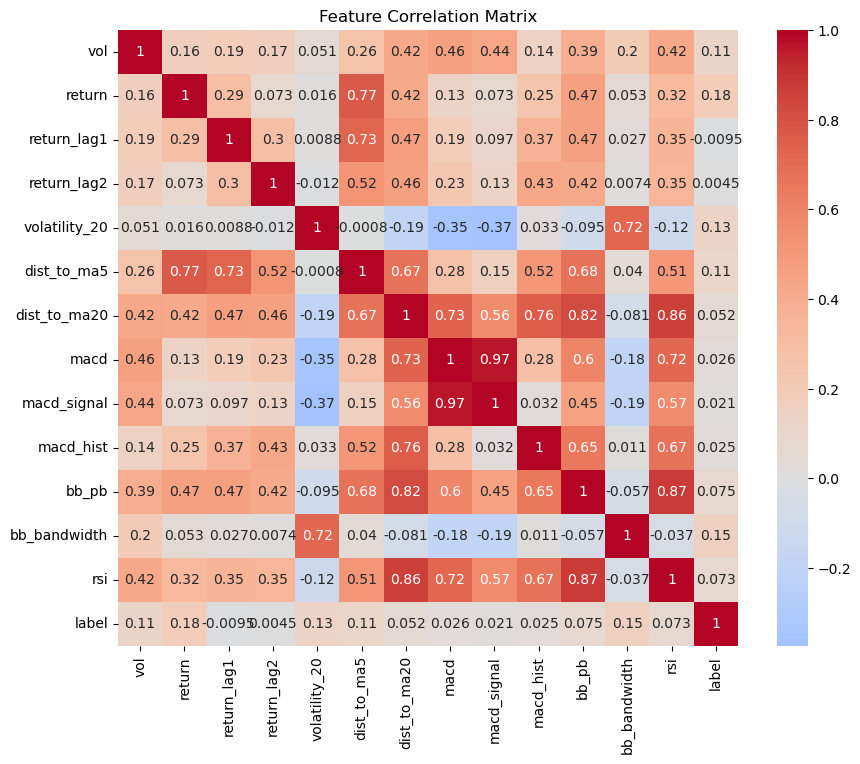

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [25]:
#Dropping multicolinearity features
df.drop(columns=['dist_to_ma20', 'macd', 'macd_signal', 'volatility_20'], inplace=True)

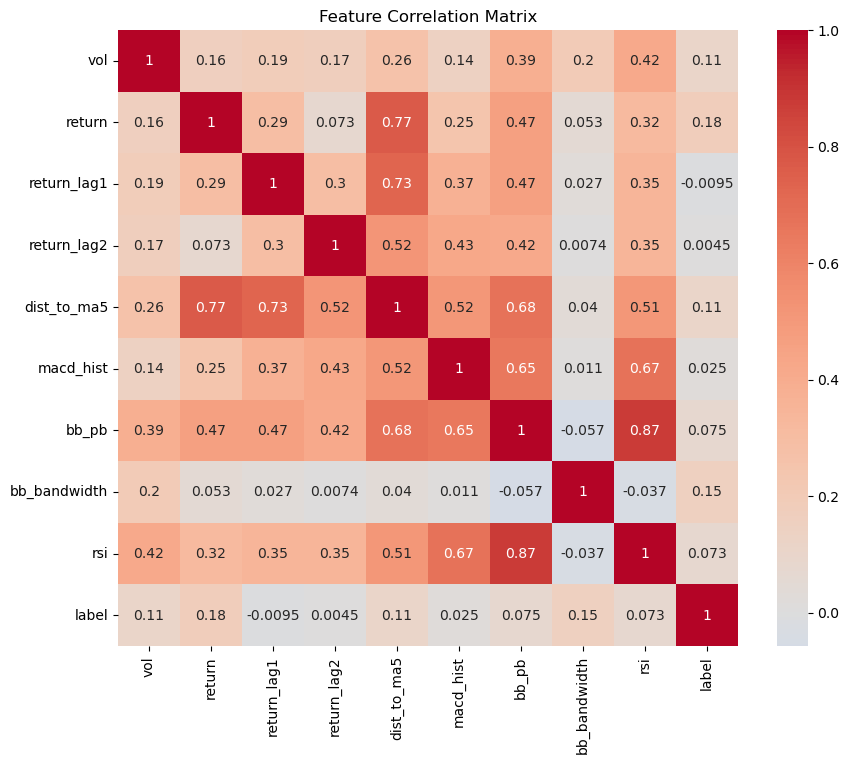

In [26]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [27]:
asset_name = "EGX100 Index" 
sns.set_theme(style="darkgrid", palette="muted")

# We calculate Cumulative Return to visualize the "price" growth
cum_return = (1 + df['return']).cumprod()

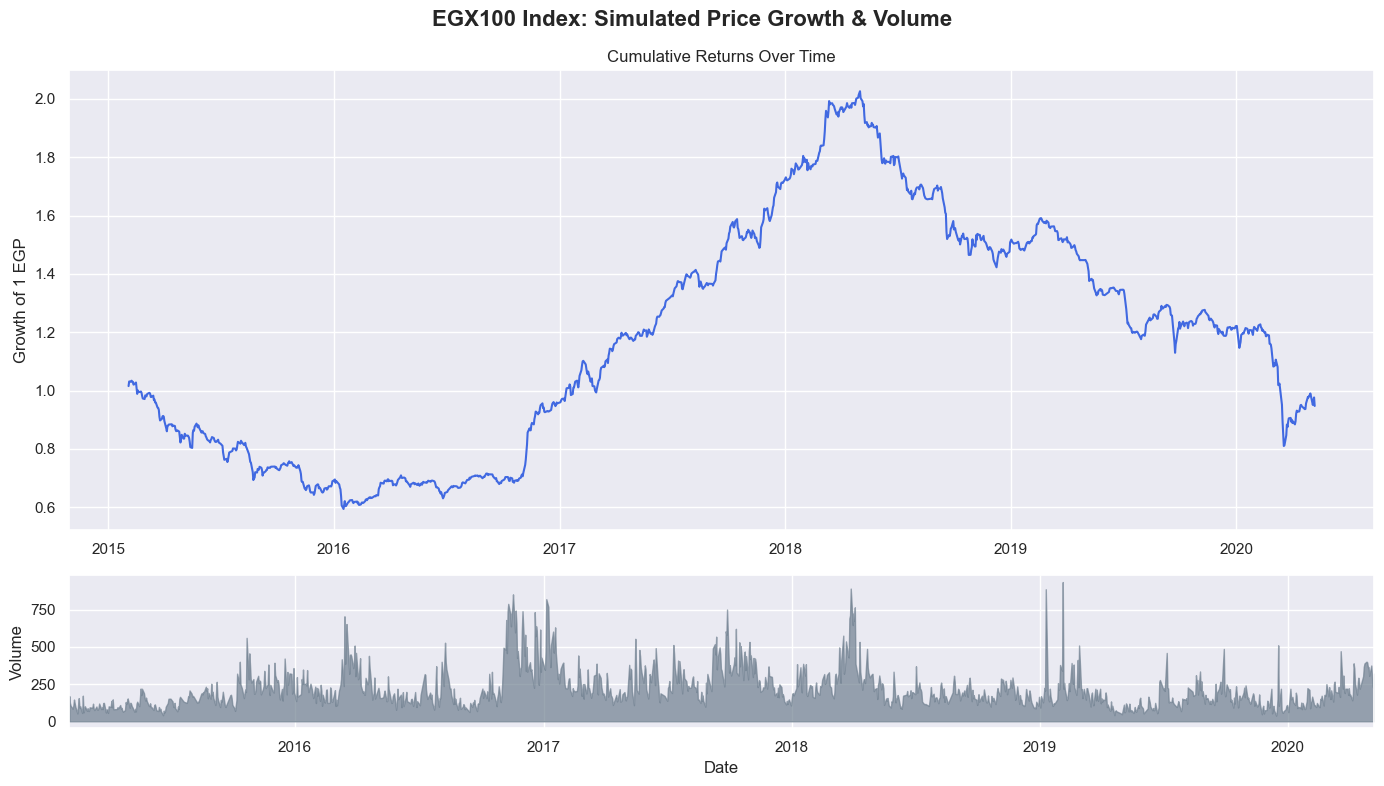

In [28]:
# ========================================================
# PLOT 1 - Macro Trend & Volume
# ========================================================
if 'vol' in df.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle(f"{asset_name}: Simulated Price Growth & Volume", fontsize=16, fontweight='bold')
    
    # Top Panel: Simulated Price (Cumulative Return)
    axes[0].plot(df.index, cum_return, color='royalblue', linewidth=1.5)
    axes[0].set_ylabel("Growth of 1 EGP")
    axes[0].set_title("Cumulative Returns Over Time")
    
    # Bottom Panel: Volume (FIXED: using fill_between instead of bar)
    axes[1].fill_between(df.index, df['vol'], color='slategray', alpha=0.7)
    axes[1].set_ylabel("Volume")
    axes[1].set_xlabel("Date")
    axes[1].margins(x=0) # Removes white space on the edges
    
else:
    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle(f"{asset_name}: Simulated Price Growth (No Volume Data)", fontsize=16, fontweight='bold')
    ax.plot(df.index, cum_return, color='royalblue', linewidth=1.5)
    ax.set_ylabel("Growth of 1 EGP")

plt.tight_layout()
plt.show()

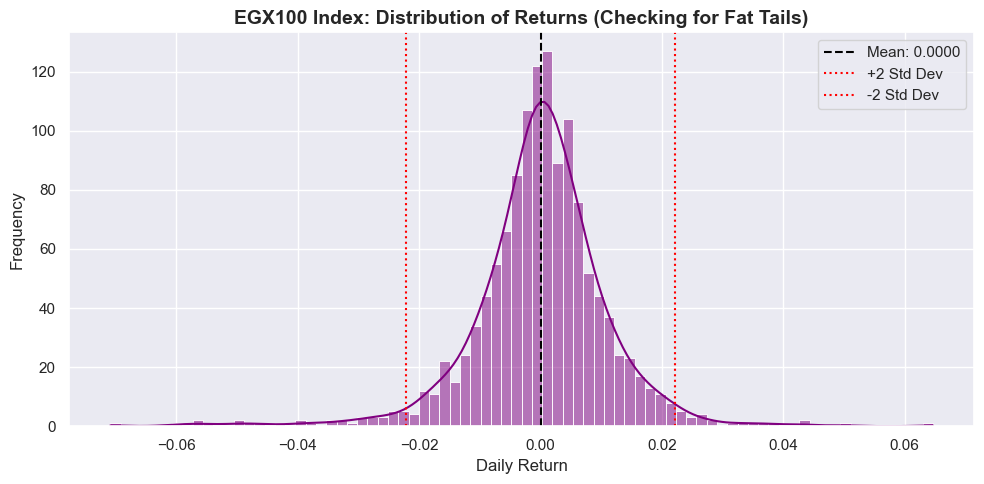

In [29]:
# ========================================================
# PLOT 2 - Distribution of Returns (Fat Tails)
# ========================================================
plt.figure(figsize=(10, 5))
sns.histplot(df['return'], kde=True, bins=80, color='purple')
plt.title(f"{asset_name}: Distribution of Returns (Checking for Fat Tails)", fontsize=14, fontweight='bold')
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

# Add statistical lines
mean_ret = df['return'].mean()
std_ret = df['return'].std()
plt.axvline(mean_ret, color='black', linestyle='--', label=f'Mean: {mean_ret:.4f}')
plt.axvline(mean_ret + (2*std_ret), color='red', linestyle=':', label='+2 Std Dev')
plt.axvline(mean_ret - (2*std_ret), color='red', linestyle=':', label='-2 Std Dev')

plt.legend()
plt.tight_layout()
plt.show()

C:\Users\moata\AppData\Local\Temp\ipykernel_25372\3776502680.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])


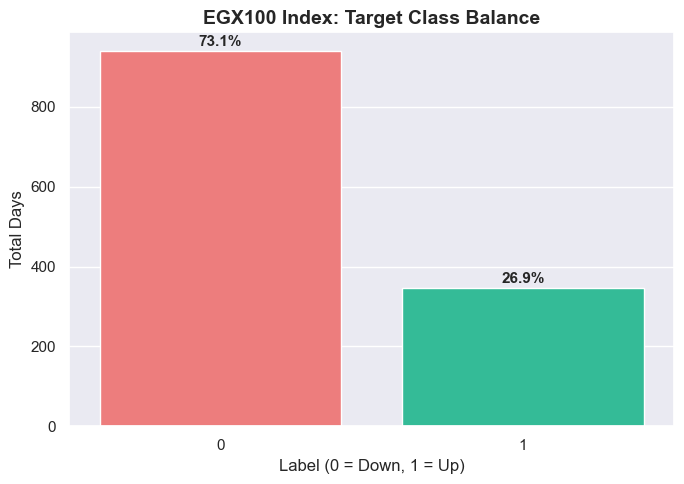

In [30]:
# ========================================================
# PLOT 3 - Target Class Balance
# ========================================================
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])
plt.title(f"{asset_name}: Target Class Balance", fontsize=14, fontweight='bold')
plt.xlabel("Label (0 = Down, 1 = Up)")
plt.ylabel("Total Days")

# Calculate and add percentages to the bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + (total * 0.01)
    ax.annotate(percentage, (x, y), ha='center', fontweight='bold', fontsize=11)
    
plt.tight_layout()
plt.show()

C:\Users\moata\AppData\Local\Temp\ipykernel_25372\2827658916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
C:\Users\moata\AppData\Local\Temp\ipykernel_25372\2827658916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
C:\Users\moata\AppData\Local\Temp\ipykernel_25372\2827658916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], pal

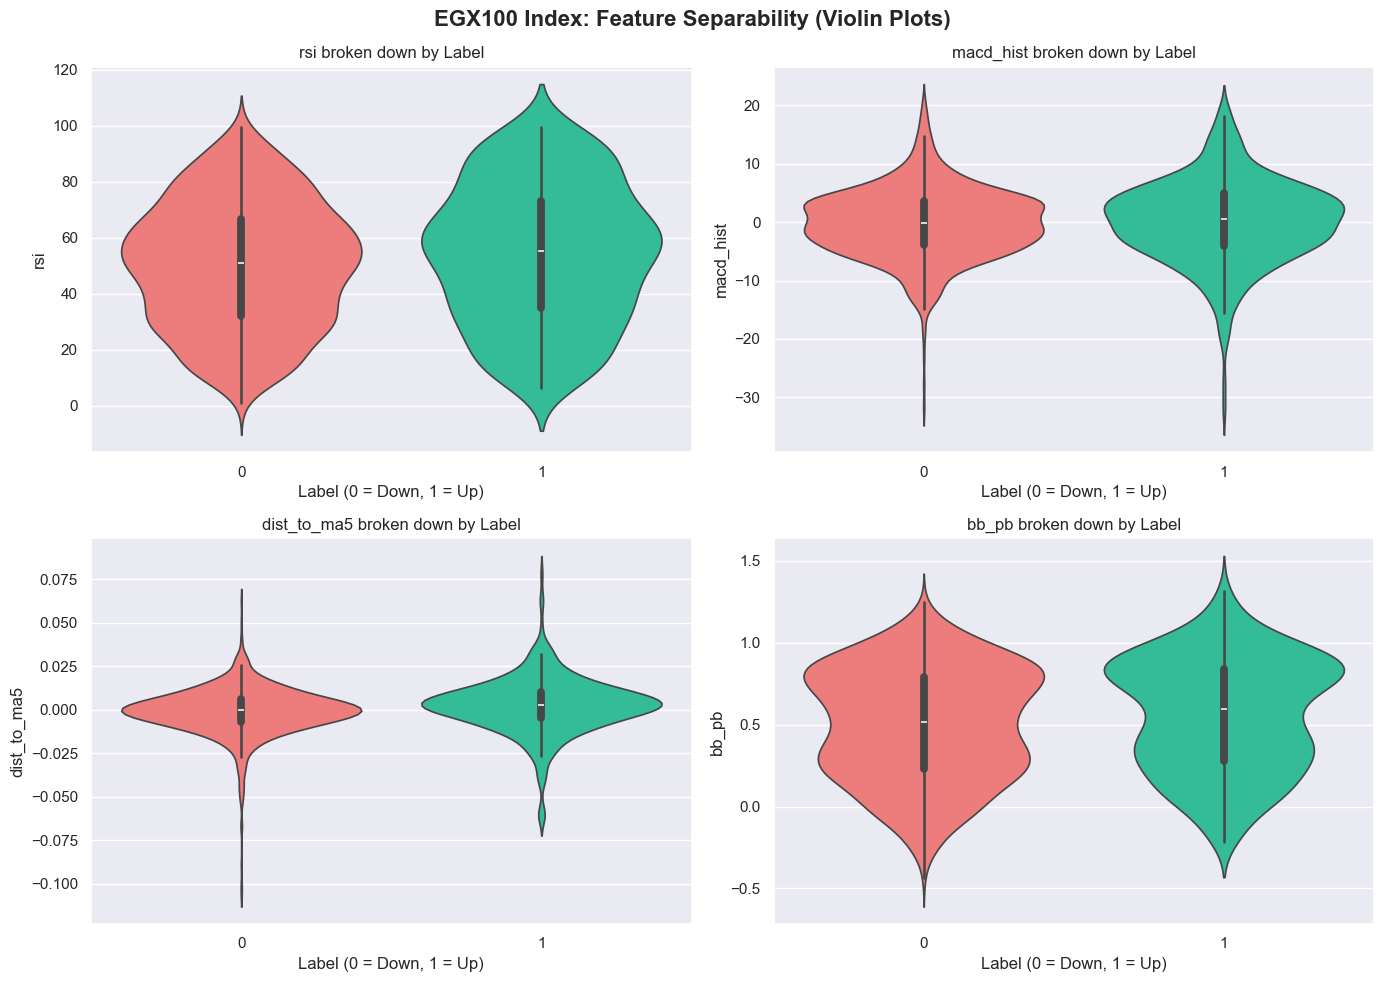

In [31]:
# ========================================================
# PLOT 4 - Feature Predictability (Violin Plots)
# ========================================================
# Selecting the 4 best ML features to plot
features = ['rsi', 'macd_hist', 'dist_to_ma5', 'bb_pb']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"{asset_name}: Feature Separability (Violin Plots)", fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
    axes[i].set_title(f"{feature} broken down by Label")
    axes[i].set_xlabel("Label (0 = Down, 1 = Up)")

plt.tight_layout()
plt.show()

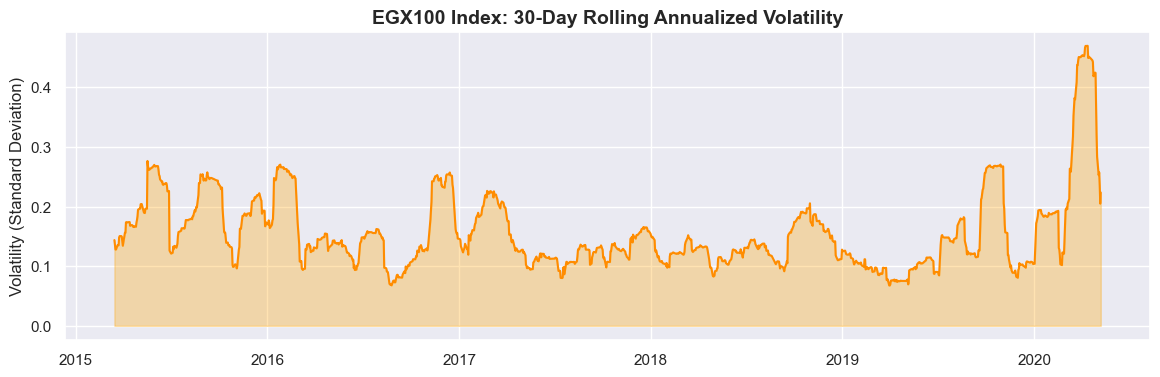

In [32]:
# CELL 7: Rolling Volatility (30-day)
df['rolling_volatility'] = df['return'].rolling(window=30).std() * np.sqrt(252) # Annualized

plt.figure(figsize=(14, 4))
plt.plot(df.index, df['rolling_volatility'], color='darkorange', linewidth=1.5)
plt.title(f"{asset_name}: 30-Day Rolling Annualized Volatility", fontsize=14, fontweight='bold')
plt.ylabel("Volatility (Standard Deviation)")
plt.fill_between(df.index, df['rolling_volatility'], alpha=0.3, color='orange')
plt.show()

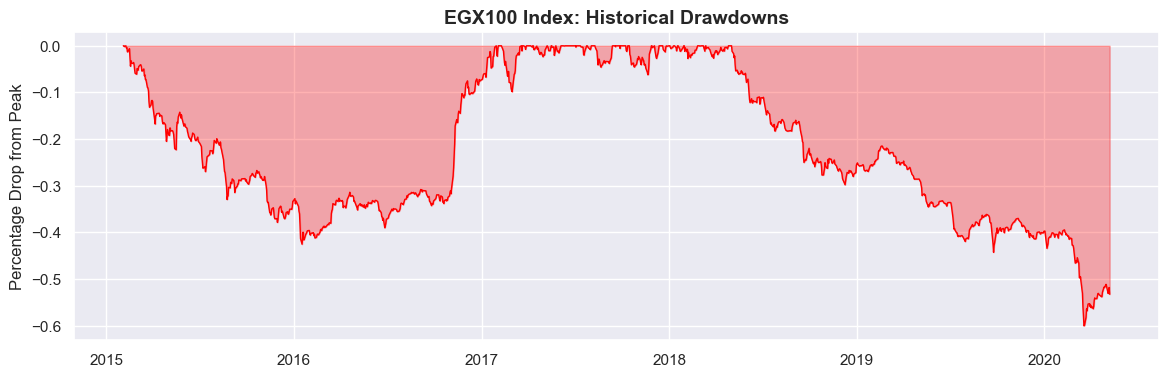

In [33]:
# CELL 8: Drawdown Chart
running_max = cum_return.cummax()
drawdown = (cum_return - running_max) / running_max

plt.figure(figsize=(14, 4))
plt.plot(df.index, drawdown, color='red', linewidth=1)
plt.fill_between(df.index, drawdown, 0, color='red', alpha=0.3)
plt.title(f"{asset_name}: Historical Drawdowns", fontsize=14, fontweight='bold')
plt.ylabel("Percentage Drop from Peak")
plt.show()

In [34]:
df.to_csv('final_data/final_EGX100.csv')